# PURITY Training (clean)

Minimal training pipeline for `PURITYHybridModel`. Losses and helpers live in `unified_reco.train_utils`.


## 1. Imports

In [1]:
import os
import sys
import torch
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import numpy as np

sys.path.append(os.path.abspath('..'))

from unified_reco.models import PURITYHybridModel
from unified_reco.dataset import PURITYDataset
from unified_reco.train_utils import PURITYLoss, format_targets_from_batch


/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Config

In [9]:
DATA_DIR     = '/mnt/c/Users/obbee/research/notebooks/ML/unified_reco/training_5_02/data_fast3.parquet'
VAL_DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/unified_reco/validation_5_02/data_fast3.parquet'
EPOCHS = 1
BATCH_SIZE = 10
MAX_HITS = 250

# task_weights = {
#     'w_atar_slice_multi':   0.2,
#     'w_node_pdg':           1.5,
#     'w_slice_pdg':          1.0,
#     'w_atar_trigger_slice': 0.5,
#     'w_pion_kinematics':    10.00,
#     'w_endpoints':          0.025,
#     'w_positron_angle':     0.5,
#     'w_lyso_condensation':  0.25,
#     'w_event_builder':      0.25,
#     'w_has_trigger_positron': 0.5,
#     'w_dead_energy': 0.1
# }

task_weights = {
    'w_atar_slice_multi':   0.05,
    'w_node_pdg':           0.5,
    'w_slice_pdg':          0.1,
    'w_endpoints':          0.025,
    'w_lyso_condensation':  0.25,

    'w_atar_trigger_slice': 0.5,
    'lambda_composition':   2.0,
    'w_time_spread':            1.0,
    'time_spread_thresh_ns':    1.0,
    'time_spread_trig_floor':   0.25,
    'time_spread_mip_floor':    0.25,

    'w_pion_kinematics':    10.0,
    'w_positron_angle':     0.5,

    'w_event_builder':      0.1,
    'w_dead_energy': 0.005
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


## 3. Data

In [3]:
dataset = PURITYDataset(DATA_DIR, max_hits=MAX_HITS)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"Events: {len(dataset)}  Batches/epoch: {len(dataloader)}")


Loading merged parquet dataset from /mnt/c/Users/obbee/research/notebooks/ML/unified_reco/training_5_02/data_fast3.parquet...
Dropped 863 events exceeding 250 hits or containing 0 hits. Active dataset size: 199137
Events: 199137  Batches/epoch: 19914


In [4]:
val_dataset = PURITYDataset(VAL_DATA_DIR, max_hits=MAX_HITS)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Val events: {len(val_dataset)}  Batches/epoch: {len(val_dataloader)}")


Loading merged parquet dataset from /mnt/c/Users/obbee/research/notebooks/ML/unified_reco/validation_5_02/data_fast3.parquet...
Dropped 100 events exceeding 250 hits or containing 0 hits. Active dataset size: 19900
Val events: 19900  Batches/epoch: 1990


## 4. Model

In [5]:
model = PURITYHybridModel()

# Optional: load checkpoint
#model = PURITYHybridModel()
state = torch.load('/mnt/c/Users/obbee/research/notebooks/ML/model_weights/PURITY_fast3_stage3.pth')
#state = {k: v for k, v in state.items() if not k.startswith('atar_trigger_classifier.')}
model.load_state_dict(state, strict=False)
model.to(device)


PURITYHybridModel(
  (atar_feature_proj): Sequential(
    (0): Linear(in_features=3, out_features=150, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=150, out_features=150, bias=True)
    (3): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
  )
  (atar_view_embedding): Embedding(2, 150)
  (lyso_encoder): Sequential(
    (0): Linear(in_features=5, out_features=150, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=150, out_features=150, bias=True)
    (3): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
  )
  (atar_blocks): ModuleList(
    (0-2): 3 x JointAttentionBlock(
      (ln1): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
      (conv): TransformerConv(150, 30, heads=5)
      (ln2): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=150, out_features=600, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.05, inplace=False)
       

In [10]:
from collections import OrderedDict

VAL_EVERY_N_EVENTS = 200000
VAL_MAX_BATCHES    = None        # set to e.g. 50 for a fast subsample, or None for full val set


def run_validation(model, val_dataloader, criterion, task_weights, device,
                   max_batches=None):
    """Returns (avg_loss, avg_loss_dict) or (None, None) if no valid batches."""
    model.train()   # match your existing convention; inference_mode handles the rest
    val_total = 0.0
    val_loss_dict = {}
    n_val = 0
    with torch.inference_mode():
        for j, batch in enumerate(val_dataloader):
            if max_batches is not None and j >= max_batches:
                break
            batch = batch.to(device)
            anchor = getattr(batch, 'atar_triggering_pion_slice', None)
            outputs = model(batch.x, batch.batch, task_weights=task_weights,
                            triggering_pion_slice=anchor)
            targets = format_targets_from_batch(batch)
            loss, loss_dict = criterion(outputs, targets, batch=batch)
            if not isinstance(loss, torch.Tensor) or torch.isnan(loss) or torch.isinf(loss):
                continue
            val_total += loss.item()
            n_val += 1
            for k, v in loss_dict.items():
                if k == 'loss_total':
                    continue
                val = v.item() if hasattr(v, 'item') else v
                val_loss_dict[k] = val_loss_dict.get(k, 0.0) + val
    if n_val == 0:
        return None, None
    return val_total / n_val, {k: v / n_val for k, v in val_loss_dict.items()}

## 5. Loss + Optimizer

Attention-bias scalars (σ parameters) get a higher learning rate so they can adapt from their physics-motivated initial values; everything else is trained at 1e-4.

In [11]:
criterion = PURITYLoss(config=task_weights)

bias_scalar_params = [
    model.sigma_t_atar_ns,
    model.sigma_t_lyso_floor_ns,
    model.sigma_t_lyso_scale_ns,
    model.angle_sigma_floor,
    model.angle_sigma_scale,
]
bias_ids = {id(p) for p in bias_scalar_params}

event_params = (
    list(model.slim_event_transformer.parameters()) +
    list(model.lyso_event_proj.parameters()) +
    list(model.atar_event_down.parameters()) +
    list(model.event_head.parameters()) +
    list(model.event_modality_emb.parameters()) +
    list(model.event_slice_emb.parameters())
)
event_params = [p for p in event_params if id(p) not in bias_ids]
event_ids = {id(p) for p in event_params}

base_params = [p for p in model.parameters()
               if id(p) not in event_ids and id(p) not in bias_ids]

optimizer = torch.optim.Adam([
    {'params': base_params,        'lr': 1e-4, 'weight_decay': 1e-5},
    {'params': event_params,       'lr': 1e-4},
    {'params': bias_scalar_params, 'lr': 1e-3, 'weight_decay': 0.0},
])


## 6. Training loop

In [12]:
#torch.autograd.set_detect_anomaly(True) #Do not enable unless there is a part of the model causing CUDA assert errors
#os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

ACCUM_STEPS = 8                # NEW: effective batch size = 10 × 8 = 80
CLIP_NORM   = 5.0              # CHANGED: was 2.0; bigger so rare strong gradients survive

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    epoch_loss_dict = {}
    events_since_val = 0          # NEW: counter for periodic val triggers
    val_count_this_epoch = 0      # NEW: numbering for mid-epoch val runs

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    optimizer.zero_grad()
    accum_count = 0

    for i, batch in enumerate(pbar):
        batch = batch.to(device)
        n_events_this_batch = batch.num_graphs    # NEW: actual count, not BATCH_SIZE

        anchor_slice = getattr(batch, 'atar_triggering_pion_slice', None)
        outputs = model(batch.x, batch.batch, task_weights=task_weights,
                        triggering_pion_slice=anchor_slice)
        targets = format_targets_from_batch(batch)
        loss, loss_dict = criterion(outputs, targets, batch=batch)

        if (not isinstance(loss, torch.Tensor) or not loss.requires_grad
                or torch.isnan(loss) or torch.isinf(loss)):
            continue

        (loss / ACCUM_STEPS).backward()
        accum_count += 1
        events_since_val += n_events_this_batch    # NEW: count by real events

        is_last_in_epoch = (i + 1) == len(dataloader)
        if accum_count == ACCUM_STEPS or is_last_in_epoch:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()
            optimizer.zero_grad()
            accum_count = 0

            # NEW: periodic validation — only at step boundaries so accumulation isn't broken
            if events_since_val >= VAL_EVERY_N_EVENTS and not is_last_in_epoch:
                val_count_this_epoch += 1
                pbar.set_description(
                    f"Epoch {epoch+1}/{EPOCHS} [val pass {val_count_this_epoch}]")
                val_loss, val_dict = run_validation(
                    model, val_dataloader, criterion, task_weights, device,
                    max_batches=VAL_MAX_BATCHES)
                if val_loss is not None:
                    val_str = " | ".join(f"{k.split('_')[-1]}: {v:.4f}"
                                         for k, v in val_dict.items())
                    print(f"\n  mid-epoch val #{val_count_this_epoch} "
                          f"(events seen: {(i+1)*BATCH_SIZE}): "
                          f"loss={val_loss:.4f} | {val_str}")
                model.train()
                events_since_val = 0
                pbar.set_description(f"Epoch {epoch+1}/{EPOCHS} [train]")

        total_loss += loss.item()
        for k, v in loss_dict.items():
            if k == 'loss_total':
                continue
            val = v.item() if hasattr(v, 'item') else v
            epoch_loss_dict[k] = epoch_loss_dict.get(k, 0.0) + val

        log_str = " | ".join(
            f"{k.split('_')[-1]}: {(v.item() if hasattr(v, 'item') else v):.4f}"
            for k, v in loss_dict.items() if k != 'loss_total'
        )
        pbar.set_postfix_str(f"Loss: {loss.item():.5f} | {log_str}")

    n_train = len(dataloader)
    train_avg_str = " | ".join(f"{k.split('_')[-1]}: {v/n_train:.4f}"
                               for k, v in epoch_loss_dict.items())
    print(f"Epoch {epoch+1} TRAIN | Avg loss: {total_loss/n_train:.4f} | {train_avg_str}")

    # End-of-epoch validation (full val set this time)
    val_loss, val_dict = run_validation(
        model, val_dataloader, criterion, task_weights, device,
        max_batches=None)
    if val_loss is not None:
        val_avg_str = " | ".join(f"{k.split('_')[-1]}: {v:.4f}"
                                 for k, v in val_dict.items())
        print(f"Epoch {epoch+1} VAL   | Avg loss: {val_loss:.4f} | {val_avg_str}")



Epoch 1/1 [train]: 100%|██████████| 19914/19914 [1:21:36<00:00,  4.07it/s, Loss: -0.14403 | multi: 0.0005 | pdg: 0.0013 | pdg: 0.0068 | ce: 0.0053 | composition: 0.0000 | slice: 0.0053 | spread: 0.0000 | kinematics: 0.0000 | PosLoss: -8.0775 | SpanLoss: 0.0093 | DirLoss: 0.0004 | MeanWidth: 0.0937 | MeanError: 0.0900 | angle: 0.0274 | condensation: 0.1276 | beta: 0.0574 | potential: 0.0697 | fraction: 0.0005 | energy: 0.0322 | builder: 0.0805]


Epoch 1 TRAIN | Avg loss: -0.0174 | multi: 0.0073 | pdg: 0.0064 | pdg: 0.0255 | ce: 0.0586 | composition: 0.0035 | slice: 0.0656 | spread: 0.0293 | kinematics: 0.0004 | PosLoss: -6.7153 | SpanLoss: 0.7606 | DirLoss: 0.0063 | MeanWidth: 0.2528 | MeanError: 0.3337 | angle: 0.0476 | condensation: 0.1399 | beta: 0.0788 | potential: 0.0581 | fraction: 0.0030 | energy: 0.0821 | builder: 0.1743
Epoch 1 VAL   | Avg loss: -0.0473 | multi: 0.0069 | pdg: 0.0064 | pdg: 0.0241 | ce: 0.0569 | composition: 0.0033 | slice: 0.0635 | spread: 0.0278 | kinematics: 0.0002 | PosLoss: -6.9392 | SpanLoss: 0.7355 | DirLoss: 0.0060 | MeanWidth: 0.2554 | MeanError: 0.3283 | angle: 0.0415 | condensation: 0.1400 | beta: 0.0786 | potential: 0.0583 | fraction: 0.0030 | energy: 0.0821 | builder: 0.1778


In [13]:
for epoch in range(EPOCHS):
    model.train()

    val_total = 0.0
    val_loss_dict = {}
    n_val_batches = 0

    val_pbar = tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]  ", leave=False)
    with torch.inference_mode():
        for batch in val_pbar:
            batch = batch.to(device)
            anchor_slice = getattr(batch, 'atar_triggering_pion_slice', None)
            outputs = model(batch.x, batch.batch, task_weights=task_weights,
                            triggering_pion_slice=anchor_slice)
            targets = format_targets_from_batch(batch)
            loss, loss_dict = criterion(outputs, targets, batch=batch)

            if not isinstance(loss, torch.Tensor) or torch.isnan(loss) or torch.isinf(loss):
                continue

            val_total += loss.item()
            n_val_batches += 1
            for k, v in loss_dict.items():
                if k == 'loss_total':
                    continue
                val = v.item() if hasattr(v, 'item') else v
                val_loss_dict[k] = val_loss_dict.get(k, 0.0) + val

    if n_val_batches > 0:
        val_avg_str = " | ".join(f"{k.split('_')[-1]}: {v/n_val_batches:.4f}"
                                 for k, v in val_loss_dict.items())
        print(f"Epoch {epoch+1} VAL   | Avg loss: {val_total/n_val_batches:.4f} | {val_avg_str}")


Epoch 1 VAL   | Avg loss: -0.0140 | multi: 0.0092 | pdg: 0.0080 | pdg: 0.0239 | ce: 0.0896 | composition: 0.0167 | slice: 0.0930 | kinematics: 0.0003 | PosLoss: -6.3984 | SpanLoss: 0.8557 | DirLoss: 0.0075 | MeanWidth: 0.2704 | MeanError: 0.3500 | angle: 0.0625 | condensation: 0.1776 | beta: 0.0941 | potential: 0.0762 | fraction: 0.0074 | energy: 0.0842 | builder: 0.2321


## 7. Save

In [ ]:
#torch.save(model.state_dict(),
#   '/mnt/c/Users/obbee/research/notebooks/ML/model_weights/PURITY_5_01_26.pth')

#torch.save(model.state_dict(),
#   '/mnt/c/Users/obbee/research/notebooks/ML/model_weights/PURITY_fast3_stage6.pth')


In [16]:
def find_failed_trigger_events(dataset_obj, model_obj, n_events=None,
                               threshold=0.5, mode='any', sort='severity',
                               verbose=True):
    """
    Scan events and return those where the ATAR per-slice trigger classifier
    misclassifies at least one slice. Also aggregates role-head diagnostics
    (per-class CE, confusion matrix) across all scanned events.

    mode   : 'any' / 'fp' / 'fn' / 'both'
    sort   : 'severity' / 'fp' / 'fn' / None

    Returns list of dicts with per-event fields, including 'role_probs'
    (shape [n_slices, 3] = P(none, μ, e)) and 'role_truth' when available.
    """
    import torch.nn.functional as F
    model_obj.train()
    device = next(model_obj.parameters()).device
    N = len(dataset_obj) if n_events is None else min(n_events, len(dataset_obj))

    failed = []
    agg_ce_per_class = {0: 0.0, 1: 0.0, 2: 0.0}
    agg_count_per_class = {0: 0, 1: 0, 2: 0}
    confusion = np.zeros((3, 3), dtype=np.int64)  # [truth, pred]

    for idx in range(N):
        data = dataset_obj[idx]
        with torch.no_grad():
            loader = DataLoader([data], batch_size=1)
            batch = next(iter(loader)).to(device)
            anchor = getattr(batch, 'atar_triggering_pion_slice', None)
            outputs = model_obj(batch.x, batch.batch,
                                task_weights={'w_atar_trigger_slice': 1.0},
                                triggering_pion_slice=anchor)

        logits = outputs.get('atar_trigger_logits')
        num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)
        if logits is None or num_atar_tokens == 0:
            continue

        p_slice = torch.sigmoid(logits).reshape(-1)[:num_atar_tokens].cpu()
        pred_slice = (p_slice > threshold)

        if hasattr(batch, 'atar_slice_trigger_target') and batch.atar_slice_trigger_target is not None:
            truth = batch.atar_slice_trigger_target.cpu().bool()
        else:
            is_atar = (batch.x[:, 5] > 0.5) | (batch.x[:, 6] > 0.5)
            valid_slice_mask = outputs['valid_slice_mask'].cpu()
            num_slices_max = outputs['num_slices_max']
            global_slice_ids = (batch.batch[is_atar] * num_slices_max
                                + batch.x[is_atar, 8].long()).cpu()
            hit_truth = batch.is_trigger_target[is_atar].cpu().float()
            slice_sum = torch.zeros(valid_slice_mask.size(0))
            slice_cnt = torch.zeros(valid_slice_mask.size(0))
            slice_sum.index_add_(0, global_slice_ids, hit_truth)
            slice_cnt.index_add_(0, global_slice_ids, torch.ones_like(hit_truth))
            truth = ((slice_sum / slice_cnt.clamp(min=1)) > 0.5)[valid_slice_mask]

        n = min(len(p_slice), len(truth))
        if n == 0:
            continue
        p_slice, pred_slice, truth = p_slice[:n], pred_slice[:n], truth[:n]

        # --- Role-head diagnostics ---
        role_logits = outputs.get('atar_role_logits')
        anchor_mask = outputs.get('atar_anchor_slice_mask')
        role_truth_batch = getattr(batch, 'atar_slice_role_target', None)

        role_probs_np = None
        role_truth_np = None
        if role_logits is not None and role_truth_batch is not None:
            rl_cpu = role_logits.detach().cpu()[:n]
            rp = F.softmax(rl_cpu, dim=-1)
            rt = role_truth_batch.long().cpu()[:n]
            am = (anchor_mask.cpu()[:n] if anchor_mask is not None
                  else torch.zeros(n, dtype=torch.bool))

            pred_cls = rp.argmax(dim=-1)
            for s in range(n):
                if am[s]:
                    continue
                t_cls = int(rt[s].item())
                p_cls = int(pred_cls[s].item())
                if 0 <= t_cls < 3:
                    ce_s = -torch.log(rp[s, t_cls].clamp(min=1e-12)).item()
                    agg_ce_per_class[t_cls] += ce_s
                    agg_count_per_class[t_cls] += 1
                    if 0 <= p_cls < 3:
                        confusion[t_cls, p_cls] += 1

            role_probs_np = rp.numpy()
            role_truth_np = rt.numpy()

        fp = pred_slice & ~truth
        fn = ~pred_slice & truth
        n_fp, n_fn = int(fp.sum()), int(fn.sum())

        if mode == 'any':    failed_flag = (n_fp + n_fn) > 0
        elif mode == 'fp':   failed_flag = n_fp > 0
        elif mode == 'fn':   failed_flag = n_fn > 0
        elif mode == 'both': failed_flag = (n_fp > 0) and (n_fn > 0)
        else: raise ValueError(f"Unknown mode: {mode}")

        if failed_flag:
            failed.append({
                'idx'         : idx,
                'n_slices'    : n,
                'n_fp'        : n_fp,
                'n_fn'        : n_fn,
                'slice_probs' : p_slice.numpy(),
                'slice_truth' : truth.numpy(),
                'slice_pred'  : pred_slice.numpy(),
                'role_probs'  : role_probs_np,
                'role_truth'  : role_truth_np,
            })

    if sort == 'severity':
        failed.sort(key=lambda f: f['n_fp'] + f['n_fn'], reverse=True)
    elif sort == 'fp':
        failed.sort(key=lambda f: f['n_fp'], reverse=True)
    elif sort == 'fn':
        failed.sort(key=lambda f: f['n_fn'], reverse=True)

    if verbose:
        print(f"Scanned {N} events → {len(failed)} failures "
              f"(mode={mode}, threshold={threshold})")
        if failed:
            avg_fp = np.mean([f['n_fp'] for f in failed])
            avg_fn = np.mean([f['n_fn'] for f in failed])
            print(f"  avg FP slices/event = {avg_fp:.2f}, "
                  f"avg FN slices/event = {avg_fn:.2f}")
            for f in failed[:10]:
                print(f"  event {f['idx']:>6d}: FP={f['n_fp']}  FN={f['n_fn']}  "
                      f"n_slices={f['n_slices']}")
                if f['role_probs'] is not None:
                    for s in range(f['n_slices']):
                        p = f['role_probs'][s]
                        t = int(f['role_truth'][s])
                        mark = ''
                        if not f['slice_pred'][s] and f['slice_truth'][s]:
                            mark = ' <-- FN'
                        elif f['slice_pred'][s] and not f['slice_truth'][s]:
                            mark = ' <-- FP'
                        print(f"    s{s}: P(none,μ,e)=({p[0]:.2f},{p[1]:.2f},{p[2]:.2f}) "
                              f"p_trig={f['slice_probs'][s]:.2f} truth_role={t}{mark}")

        # Role-head summary across all scanned events
        if any(v > 0 for v in agg_count_per_class.values()):
            names = {0: 'none', 1: 'muon', 2: 'posit'}
            print(f"\n  Role-head diagnostics across {N} events (non-anchor slices):")
            for c in range(3):
                cnt = agg_count_per_class[c]
                if cnt > 0:
                    print(f"    class {c} ({names[c]}): mean CE={agg_ce_per_class[c]/cnt:.4f}  count={cnt}")
                else:
                    print(f"    class {c} ({names[c]}): no slices")
            print(f"  Confusion (rows=truth, cols=pred):")
            print(f"              pred: none    μ      e")
            for r in range(3):
                print(f"    truth={names[r]:>5s}: "
                      f"{confusion[r,0]:>6d} {confusion[r,1]:>6d} {confusion[r,2]:>6d}")

    return failed


In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.patches as mpatches

def plot_event_builder_debug(dataset_obj, model_obj, event_idx=0, threshold=0.5):
    """Plot ATAR hits colored by TP (green), TN (gray), FP (orange), FN (red)."""
    model_obj.train()
    data = dataset_obj[event_idx]
    
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        anchor = getattr(batch, 'atar_triggering_pion_slice', None)
        outputs = model_obj(batch.x, batch.batch,
                            task_weights={'w_atar_trigger_slice': 1.0},
                            triggering_pion_slice=anchor)

    
    event_logits = outputs.get('atar_trigger_logits')
    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)
    if event_logits is None or num_atar_tokens == 0:
        print(f"Event {event_idx}: no ATAR event builder output")
        return
    
    # Per-slice predictions
    p_atar = torch.sigmoid(event_logits.squeeze(-1))[:num_atar_tokens].cpu()
    pred_trigger_slice = (p_atar > threshold)
    
    # Map slices back to hits
    is_atar = (batch.x[:, 5] > 0.5) | (batch.x[:, 6] > 0.5)
    valid_slice_mask = outputs['valid_slice_mask'].cpu()
    num_slices_max = outputs['num_slices_max']
    global_slice_ids = (batch.batch[is_atar] * num_slices_max + batch.x[is_atar, 8].long()).cpu()
    
    hit_is_valid = valid_slice_mask[global_slice_ids]
    mapped_slice_indices = torch.cumsum(valid_slice_mask.long(), dim=0) - 1
    
    # Per-hit truth and prediction
    hit_truth = batch.is_trigger_target[is_atar].cpu().bool()
    hit_pred = torch.zeros_like(hit_truth)
    valid_idx = mapped_slice_indices[global_slice_ids[hit_is_valid]]
    hit_pred[hit_is_valid] = pred_trigger_slice[valid_idx]
    
    # Classify: TP, TN, FP, FN
    tp = hit_pred & hit_truth
    tn = ~hit_pred & ~hit_truth
    fp = hit_pred & ~hit_truth
    fn = ~hit_pred & hit_truth
    
    colors = np.full(len(hit_truth), 'gray', dtype=object)  # TN = gray
    colors[tp.numpy()] = 'green'   # TP
    colors[fp.numpy()] = 'orange'  # FP
    colors[fn.numpy()] = 'red'     # FN
    
    # Geometry from dataframe
    row = dataset_obj.df.iloc[event_idx]
    atar_x = np.array(row['atar_x'])
    atar_y = np.array(row['atar_y'])
    atar_z = np.array(row['atar_z'])
    atar_view = np.array(row['atar_view'])
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_s = np.clip(20 + atar_E * 150, 1, 500)
    
    # Stats
    n_tp, n_tn, n_fp, n_fn = tp.sum().item(), tn.sum().item(), fp.sum().item(), fn.sum().item()
    accuracy = (n_tp + n_tn) / max(n_tp + n_tn + n_fp + n_fn, 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx} — ATAR Event Builder  '
                 f'(TP:{n_tp} TN:{n_tn} FP:{n_fp} FN:{n_fn}  Acc:{accuracy:.1%})', fontsize=14)
    
    # XZ
    mask_xz = (atar_view == 0)
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz],
                c=colors[mask_xz], s=atar_s[mask_xz], alpha=0.8, edgecolors='k', linewidths=0.3)
    ax1.set_xlabel('Z [mm]'); ax1.set_ylabel('X [mm]')
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-13.5, 13.5)
    ax1.yaxis.set_major_locator(MultipleLocator(2.5))
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.set_title("X-Z Projection")
    
    # YZ
    mask_yz = (atar_view == 1)
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz],
                c=colors[mask_yz], s=atar_s[mask_yz], alpha=0.8, edgecolors='k', linewidths=0.3)
    ax2.set_xlabel('Z [mm]'); ax2.set_ylabel('Y [mm]')
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-13.5, 13.5)
    ax2.yaxis.set_major_locator(MultipleLocator(2.5))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_title("Y-Z Projection")
    
    handles = [
        mpatches.Patch(color='green', label=f'TP ({n_tp})'),
        mpatches.Patch(color='gray', label=f'TN ({n_tn})'),
        mpatches.Patch(color='orange', label=f'FP ({n_fp})'),
        mpatches.Patch(color='red', label=f'FN ({n_fn})')
    ]
    ax1.legend(handles=handles, loc='upper left')
    ax2.legend(handles=handles, loc='upper left')
    
    # Per-slice probability bar chart
    fig2, ax3 = plt.subplots(figsize=(max(8, num_atar_tokens * 0.5), 4))
    slice_probs = p_atar.numpy()
    
    # Per-slice ground truth
    slice_trigger_sum = torch.zeros(valid_slice_mask.size(0))
    slice_count = torch.zeros(valid_slice_mask.size(0))
    slice_trigger_sum.index_add_(0, global_slice_ids, hit_truth.float())
    slice_count.index_add_(0, global_slice_ids, torch.ones(global_slice_ids.size(0)))
    slice_gt = ((slice_trigger_sum / slice_count.clamp(min=1)) > 0.5)[valid_slice_mask].numpy()
    
    bar_colors = ['green' if gt else 'gray' for gt in slice_gt[:len(slice_probs)]]
    ax3.bar(range(len(slice_probs)), slice_probs, color=bar_colors, edgecolor='k', linewidth=0.5)
    ax3.axhline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
    ax3.set_xlabel('Slice Index'); ax3.set_ylabel('Trigger Probability')
    ax3.set_title(f'Event {event_idx} — Per-Slice Trigger Probability (bar color = ground truth)')
    ax3.legend()
    ax3.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()


In [18]:
def inspect_failed_event(dataset_obj, idx):
    """Pull raw hit data for one event and break down each slice."""
    row = dataset_obj.df.iloc[idx]
    atar_slice = np.array(row['atar_slice'])
    atar_origin = np.array(row.get('atar_origin', np.zeros(len(atar_slice))))
    atar_pdg = np.array(row['atar_pdg'])  # bitmask: 1<<0 pi, 1<<1 mu, 1<<2 e
    atar_t = np.array(row.get('atar_slice_mean_t', np.zeros(len(atar_slice))))
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros(len(atar_slice))
    atar_z = np.array(row['atar_z'])

    unique_slices = np.unique(atar_slice)
    print(f"\n=== Event {idx} ===")
    print(f"Total hits: {len(atar_slice)}, slices: {len(unique_slices)}")

    for s_id in sorted(unique_slices):
        m = (atar_slice == s_id)
        n_hits = m.sum()
        n_trigger_origin = (atar_origin[m] == 0).sum()
        has_pion = bool(((atar_pdg[m] & 1) > 0).any())
        has_muon = bool(((atar_pdg[m] & 2) > 0).any())
        has_posi = bool(((atar_pdg[m] & 4) > 0).any())
        mean_t = atar_t[m].mean() if n_hits > 0 else float('nan')
        mean_E = atar_E[m].mean() if n_hits > 0 else float('nan')
        z_range = (atar_z[m].min(), atar_z[m].max()) if n_hits > 0 else (0, 0)

        mix_flags = ''.join(['π' if has_pion else '_',
                             'μ' if has_muon else '_',
                             'e' if has_posi else '_'])
        print(f"  slice {s_id}: n={n_hits:>3d}  trig_origin={n_trigger_origin:>3d}/{n_hits}  "
              f"pdg=[{mix_flags}]  t̄={mean_t:+.2f}  Ē={mean_E:.3f}  z∈[{z_range[0]:.1f},{z_range[1]:.1f}]")

# Usage
for idx in [146, 198, 324, 382, 401, 411]:
    inspect_failed_event(dataset, idx)



=== Event 146 ===
Total hits: 37, slices: 3
  slice 1: n= 30  trig_origin= 30/30  pdg=[πμ_]  t̄=+0.41  Ē=0.370  z∈[-0.0,3.5]
  slice 2: n=  3  trig_origin=  3/3  pdg=[_μ_]  t̄=+1.78  Ē=1.125  z∈[3.5,3.5]
  slice 3: n=  4  trig_origin=  4/4  pdg=[__e]  t̄=+355.21  Ē=0.052  z∈[2.9,3.4]

=== Event 198 ===
Total hits: 46, slices: 3
  slice 1: n= 25  trig_origin= 25/25  pdg=[π__]  t̄=+0.39  Ē=0.403  z∈[-0.0,3.3]
  slice 2: n=  4  trig_origin=  4/4  pdg=[_μ_]  t̄=+34.01  Ē=0.925  z∈[3.2,3.3]
  slice 3: n= 17  trig_origin= 17/17  pdg=[__e]  t̄=+124.17  Ē=0.035  z∈[1.2,3.2]

=== Event 324 ===
Total hits: 124, slices: 6
  slice 1: n= 29  trig_origin=  0/29  pdg=[π__]  t̄=-35.07  Ē=0.368  z∈[-0.0,3.7]
  slice 2: n=  4  trig_origin=  0/4  pdg=[_μ_]  t̄=-30.17  Ē=0.944  z∈[3.7,4.0]
  slice 3: n= 30  trig_origin=  0/30  pdg=[πμ_]  t̄=-2.80  Ē=0.365  z∈[-0.0,3.8]
  slice 4: n= 32  trig_origin= 28/32  pdg=[πμ_]  t̄=+0.15  Ē=0.439  z∈[-0.0,4.1]
  slice 5: n=  8  trig_origin=  8/8  pdg=[_μ_]  t̄=+21.3

In [20]:
def inspect_slice_endpoints(dataset_obj, model_obj, idx, device=None):
    import numpy as np
    import torch.nn.functional as F
    NORM_POS_ATAR = 10.0

    if device is None:
        device = next(model_obj.parameters()).device
    data = dataset_obj[idx]

    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        anchor = getattr(batch, 'atar_triggering_pion_slice', None)
        outputs = model_obj(batch.x, batch.batch,
                            task_weights={'w_atar_trigger_slice': 1.0,
                                          'w_endpoints': 1.0},
                            triggering_pion_slice=anchor)

    is_atar_x = (batch.x[:, 5] > 0.5)
    is_atar_y = (batch.x[:, 6] > 0.5)
    is_atar = is_atar_x | is_atar_y
    slice_ids_dense = batch.x[:, 8].long().cpu()
    num_slices_max = outputs['num_slices_max']
    valid_slice_mask = outputs['valid_slice_mask'].cpu()
    e_hits = batch.x[:, 3].cpu().numpy()

    s_start = batch.atar_slice_start_target.cpu().numpy() * NORM_POS_ATAR
    s_stop  = batch.atar_slice_stop_target.cpu().numpy()  * NORM_POS_ATAR

    pred = outputs['atar_endpoints'].cpu().numpy()
    pred_start    = pred[:, 0, :, 1] * NORM_POS_ATAR
    pred_stop     = pred[:, 1, :, 1] * NORM_POS_ATAR
    pred_start_lo = pred[:, 0, :, 0] * NORM_POS_ATAR
    pred_start_hi = pred[:, 0, :, 2] * NORM_POS_ATAR

    role_truth = batch.atar_slice_role_target.cpu().numpy()
    if 'atar_role_logits' in outputs:
        role_probs = F.softmax(outputs['atar_role_logits'].cpu(), dim=-1).numpy()
    else:
        role_probs = None

    # CPU-only indexing
    batch_idx_cpu = batch.batch.cpu()
    is_atar_cpu = is_atar.cpu()
    is_atar_x_cpu = is_atar_x.cpu()
    global_slice_ids = (batch_idx_cpu[is_atar_cpu] * num_slices_max
                        + slice_ids_dense[is_atar_cpu])

    valid_global = torch.nonzero(valid_slice_mask).squeeze(1)
    local_to_global = {int(g.item()): i for i, g in enumerate(valid_global)}

    n_valid = int(valid_slice_mask.sum().item())
    nhits_x = np.zeros(n_valid, dtype=np.int64)
    nhits_y = np.zeros(n_valid, dtype=np.int64)
    E_total = np.zeros(n_valid, dtype=np.float64)

    is_atar_cpu_arr = is_atar_cpu.numpy()
    atar_hit_indices = np.where(is_atar_cpu_arr)[0]
    for k, hit_i in enumerate(atar_hit_indices):
        g = int(global_slice_ids[k].item())
        if g not in local_to_global:
            continue
        loc = local_to_global[g]
        if bool(is_atar_x_cpu[hit_i]):
            nhits_x[loc] += 1
        else:
            nhits_y[loc] += 1
        E_total[loc] += e_hits[hit_i]

    print(f"\n=== Event {idx} — Endpoint dump ===")
    for s in range(n_valid):
        s0 = s_start[s]; s1 = s_stop[s]
        p0 = pred_start[s]; p1 = pred_stop[s]
        span_truth = np.linalg.norm(s1 - s0)
        span_pred  = np.linalg.norm(p1 - p0)
        e_start_sigma = np.linalg.norm(pred_start_hi[s] - pred_start_lo[s]) / 2
        rt = int(role_truth[s]) if s < len(role_truth) else -1
        rp_str = ''
        if role_probs is not None:
            p = role_probs[s]
            rp_str = f"  P(n,μ,e)=({p[0]:.2f},{p[1]:.2f},{p[2]:.2f})"
        print(f"  slice {s}: n_x={nhits_x[s]:>3d} n_y={nhits_y[s]:>3d}  "
              f"Etot={E_total[s]:.3f}  truth_role={rt}{rp_str}")
        print(f"    truth  start=({s0[0]:+5.2f},{s0[1]:+5.2f},{s0[2]:+5.2f})  "
              f"stop=({s1[0]:+5.2f},{s1[1]:+5.2f},{s1[2]:+5.2f})  |Δ|={span_truth:.2f}")
        print(f"    pred   start=({p0[0]:+5.2f},{p0[1]:+5.2f},{p0[2]:+5.2f})  "
              f"stop=({p1[0]:+5.2f},{p1[1]:+5.2f},{p1[2]:+5.2f})  |Δ|={span_pred:.2f}  "
              f"σ_start≈{e_start_sigma:.2f}mm")


# Usage:
for idx in [146, 198, 298, 324, 382, 401, 411]:
    inspect_slice_endpoints(dataset, model, idx)



=== Event 146 — Endpoint dump ===
  slice 0: n_x= 14 n_y= 16  Etot=11.099  truth_role=0  P(n,μ,e)=(1.00,0.00,0.00)
    truth  start=(-9.03,+0.00,-0.01)  stop=(-9.44,-0.10,+3.54)  |Δ|=3.57
    pred   start=(-8.98,-0.02,-0.01)  stop=(-9.40,-0.11,+3.54)  |Δ|=3.57  σ_start≈0.03mm
  slice 1: n_x=  0 n_y=  3  Etot=3.375  truth_role=1  P(n,μ,e)=(0.00,1.00,0.00)
    truth  start=(-9.70,+0.52,+3.47)  stop=(-9.55,+0.16,+3.51)  |Δ|=0.40
    pred   start=(-9.73,+0.52,+3.47)  stop=(-9.65,+0.04,+3.51)  |Δ|=0.49  σ_start≈0.21mm
  slice 2: n_x=  2 n_y=  2  Etot=0.207  truth_role=2  P(n,μ,e)=(0.00,0.00,1.00)
    truth  start=(-10.06,-0.23,+2.90)  stop=(-9.76,+0.45,+3.38)  |Δ|=0.88
    pred   start=(-10.02,-0.31,+2.91)  stop=(-9.70,-0.05,+3.26)  |Δ|=0.54  σ_start≈0.12mm

=== Event 198 — Endpoint dump ===
  slice 0: n_x= 13 n_y= 12  Etot=10.085  truth_role=0  P(n,μ,e)=(1.00,0.00,0.00)
    truth  start=(-7.97,+1.53,-0.01)  stop=(-7.53,+1.56,+3.28)  |Δ|=3.32
    pred   start=(-7.92,+1.53,-0.01)  stop=(-7.

In [7]:
import torch.nn.functional as F

raw  = model.kernel_alpha.detach().cpu()
eff  = F.softplus(raw)
print(f"kernel_alpha raw:      {raw.tolist()}          (init = [-2.0, -2.0, -2.0])")
print(f"kernel_alpha softplus: {eff.tolist()}   (init ≈ [0.127, 0.127, 0.127])")
print(f"max |Δ| from init:     {(raw - (-2.0)).abs().max().item():.4f}")


kernel_alpha raw:      [-2.0552356243133545, -2.0741231441497803, -1.9886783361434937]          (init = [-2.0, -2.0, -2.0])
kernel_alpha softplus: [0.12050168961286545, 0.11837536841630936, 0.12828433513641357]   (init ≈ [0.127, 0.127, 0.127])
max |Δ| from init:     0.0741


In [21]:
# 1) find the failures
bad = find_failed_trigger_events(dataset, model, n_events=500,
                                 threshold=0.5, mode='any', sort='severity')

# 2) extract indices
failed_indices = [f['idx'] for f in bad]


Scanned 500 events → 2 failures (mode=any, threshold=0.5)
  avg FP slices/event = 0.00, avg FN slices/event = 1.00
  event    289: FP=0  FN=1  n_slices=6
    s0: P(none,μ,e)=(1.00,0.00,0.00) p_trig=0.00 truth_role=0
    s1: P(none,μ,e)=(1.00,0.00,0.00) p_trig=0.00 truth_role=0
    s2: P(none,μ,e)=(1.00,0.00,0.00) p_trig=0.00 truth_role=0
    s3: P(none,μ,e)=(1.00,0.00,0.00) p_trig=1.00 truth_role=0
    s4: P(none,μ,e)=(0.53,0.47,0.00) p_trig=0.47 truth_role=1 <-- FN
    s5: P(none,μ,e)=(1.00,0.00,0.00) p_trig=0.00 truth_role=0
  event    356: FP=0  FN=1  n_slices=6
    s0: P(none,μ,e)=(1.00,0.00,0.00) p_trig=0.00 truth_role=0
    s1: P(none,μ,e)=(1.00,0.00,0.00) p_trig=0.00 truth_role=0
    s2: P(none,μ,e)=(1.00,0.00,0.00) p_trig=1.00 truth_role=0
    s3: P(none,μ,e)=(0.04,0.96,0.00) p_trig=0.96 truth_role=1
    s4: P(none,μ,e)=(0.55,0.00,0.45) p_trig=0.45 truth_role=2 <-- FN
    s5: P(none,μ,e)=(1.00,0.00,0.00) p_trig=0.00 truth_role=0

  Role-head diagnostics across 500 events (non-a


=== event 289 — FP=0 FN=1 ===


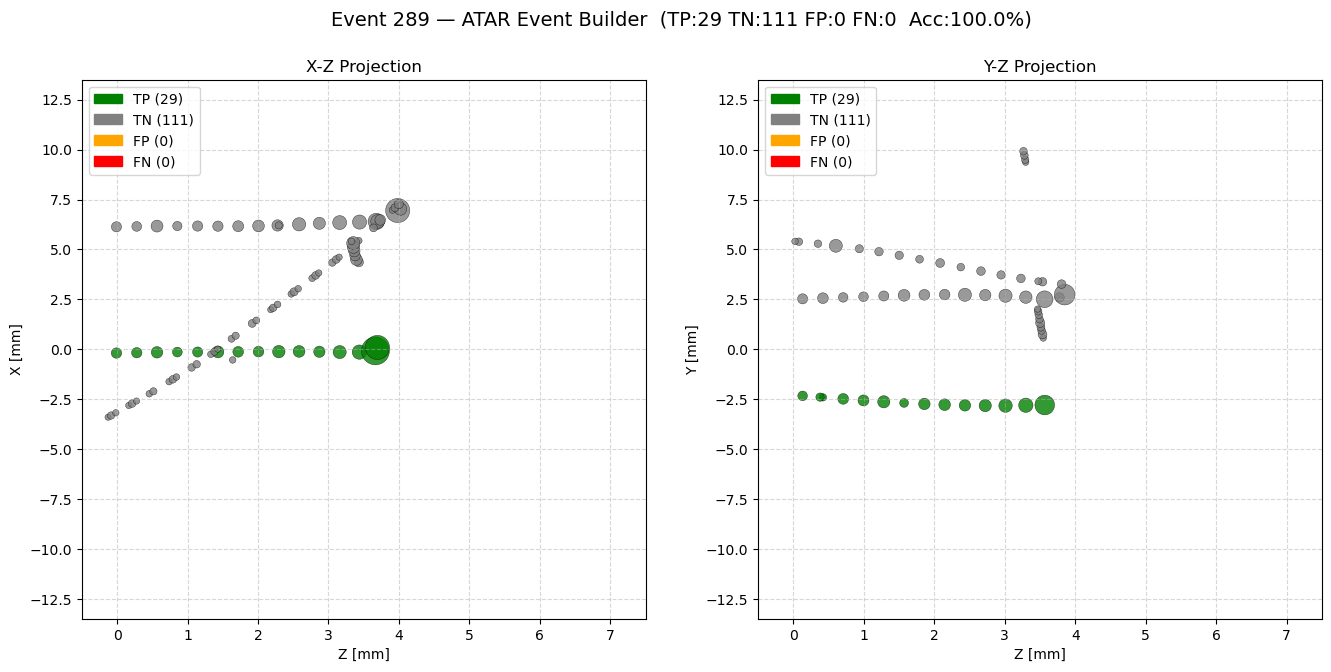

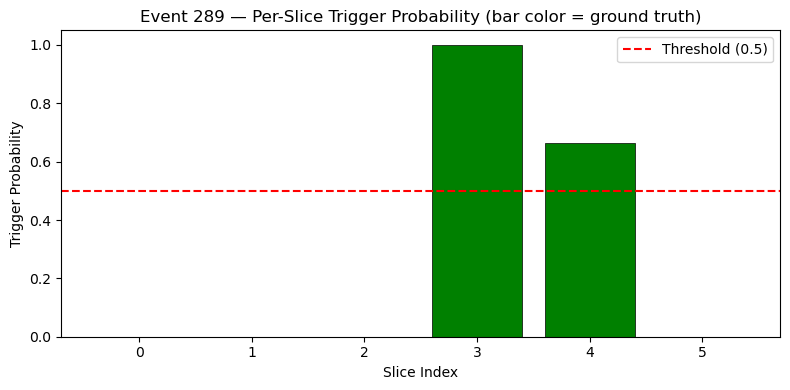


=== event 356 — FP=0 FN=1 ===


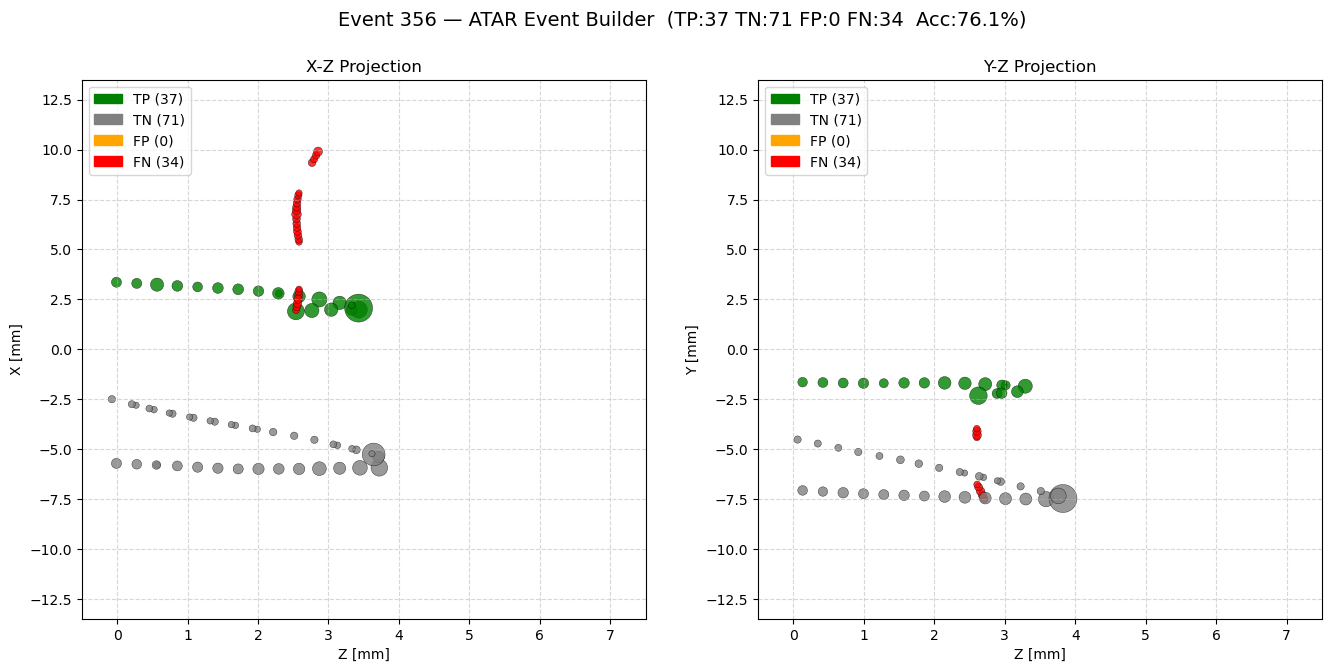

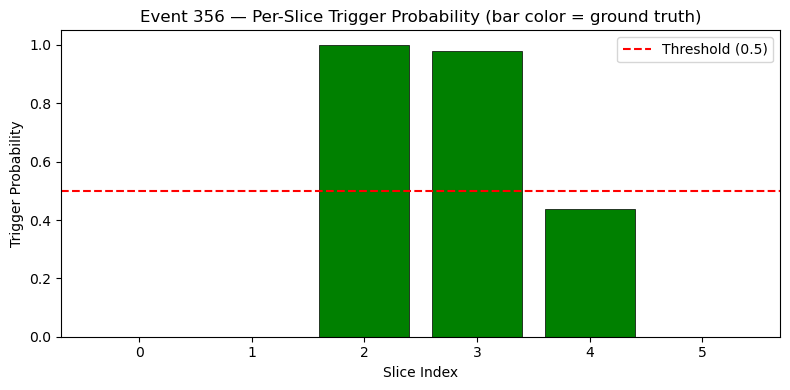

In [22]:
for f in bad[:15]:
    print(f"\n=== event {f['idx']} — FP={f['n_fp']} FN={f['n_fn']} ===")
    plot_event_builder_debug(dataset, model, event_idx=f['idx'], threshold=0.5)

In [14]:
import matplotlib.pyplot as plt

def plot_event_builder_confusion(dataset_obj, model_obj, event_idx=0, trigger_threshold=0.5):
    """
    LYSO event display colored by TP/FP/TN/FN for event builder trigger classification.
    Uses assignment-weighted mixture probability per hit (matching the loss function).
    """
    model_obj.train()
    device = next(model_obj.parameters()).device
    data = dataset_obj[event_idx]

    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_lyso_condensation': 1.0, 'w_event_builder': 1.0})

    # --- Filter LYSO hits ---
    is_lyso = (batch.x[:, 7] > 0.5).cpu()
    if not is_lyso.any():
        print(f"No LYSO hits in event {event_idx}")
        return

    x_orig = batch.x[is_lyso, 0].cpu().numpy() * 100.0
    y_orig = batch.x[is_lyso, 1].cpu().numpy() * 100.0
    z_orig = batch.x[is_lyso, 2].cpu().numpy() * 100.0
    energy = batch.x[is_lyso, 3].cpu().numpy() * 70.0
    times  = batch.x[is_lyso, 4].cpu().numpy() * 500.0

    r = np.sqrt(x_orig**2 + y_orig**2 + z_orig**2)
    theta = np.arccos(np.clip(z_orig / r, -1.0, 1.0))
    phi = np.arctan2(y_orig, x_orig)
    proj_x = theta * np.sin(phi)
    proj_y = theta * np.cos(phi)
    marker_sizes = np.maximum(energy * 50.0, 5.0)

    # --- Ground truth ---
    targets = batch.is_trigger_target[is_lyso].cpu().numpy()  # per-hit binary

    # --- Predicted p_hit via assignment-weighted mixture ---
    lyso_assignments = outputs.get('lyso_soft_assignments')  # [N_lyso_hits, K]
    event_logits = outputs.get('unified_event_logits')
    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)

    if lyso_assignments is None or event_logits is None:
        print("Model did not produce LYSO event builder outputs")
        return

    p_tokens = torch.sigmoid(event_logits.squeeze(-1)).cpu()
    p_lyso = p_tokens[num_atar_tokens:]
    K = lyso_assignments.size(1)
    p_lyso_matrix = p_lyso.view(-1, K)  # [num_lyso_graphs, K]

    # For single-event batch, lyso_mapped_batch is all zeros
    n_lyso_hits = lyso_assignments.size(0)
    lyso_mapped_batch = torch.zeros(n_lyso_hits, dtype=torch.long)

    effective_weights = lyso_assignments.cpu()
    lyso_seed_beta = outputs.get('lyso_seed_beta')
    if lyso_seed_beta is not None:
        beta_matrix = lyso_seed_beta.cpu().view(-1, K)
        beta_broadcast = beta_matrix[lyso_mapped_batch]
        effective_weights = effective_weights * beta_broadcast

    w_sum = effective_weights.sum(dim=1).clamp(min=1e-6)
    p_hit = ((effective_weights * p_lyso_matrix[lyso_mapped_batch]).sum(dim=1) / w_sum).numpy()

    # ============================================================
    # DIAGNOSTIC PRINTOUT — per-cluster + per-hit fragmentation
    # ============================================================
    print(f"\n========== Event {event_idx} diagnostic ==========")

    # --- Per-cluster table ---
    lyso_logits = event_logits.squeeze(-1).cpu()[num_atar_tokens:].view(-1, K)[0]  # [K] for this single event
    beta_k = lyso_seed_beta.cpu().view(-1, K)[0] if lyso_seed_beta is not None else torch.zeros(K)
    p_k = p_lyso_matrix[0]  # [K]
    assignments_np = lyso_assignments.cpu().numpy()  # [N_hits, K]
    targets_t = torch.from_numpy(targets)

    print(f"\nPer-cluster summary (event {event_idx}):")
    print(f"{'k':>3} {'beta':>7} {'logit':>8} {'p_k':>7} {'n_hits(w>0.1)':>14} {'n_trig_in_cluster':>18} {'trig_purity':>12}")
    for k in range(K):
        w_k = assignments_np[:, k]
        n_assigned = int((w_k > 0.1).sum())
        # "Trigger purity": of hits weighted toward this cluster, what fraction are true trigger?
        if w_k.sum() > 1e-6:
            trig_weight = float((w_k * targets).sum())
            total_weight = float(w_k.sum())
            trig_purity = trig_weight / total_weight
        else:
            trig_purity = 0.0
        n_trig_assigned = int(((w_k > 0.1) & (targets == 1)).sum())
        print(f"{k:>3d} {beta_k[k].item():>7.3f} {lyso_logits[k].item():>+8.3f} "
            f"{p_k[k].item():>7.3f} {n_assigned:>14d} {n_trig_assigned:>18d} {trig_purity:>12.3f}")

    # --- Identify the "true trigger cluster" (cluster with highest trigger purity weighted by total weight) ---
    purities = []
    for k in range(K):
        w_k = assignments_np[:, k]
        if w_k.sum() > 1e-6:
            purities.append(float((w_k * targets).sum()) / float(w_k.sum()))
        else:
            purities.append(0.0)
    true_trig_cluster = int(np.argmax(purities))
    print(f"\nMost-trigger-aligned cluster: k={true_trig_cluster} "
        f"(purity={purities[true_trig_cluster]:.2f}, "
        f"logit={lyso_logits[true_trig_cluster].item():+.2f}, "
        f"p_k={p_k[true_trig_cluster].item():.3f})")

    # --- OC fragmentation diagnostic for true-trigger hits ---
    trig_hit_mask = targets == 1
    if trig_hit_mask.any():
        w_trig = assignments_np[trig_hit_mask]  # [n_trig, K]
        max_w_per_hit = w_trig.max(axis=1)
        n_clusters_active = (w_trig > 0.05).sum(axis=1)
        sum_w_per_hit = w_trig.sum(axis=1)
        print(f"\nTrue trigger hits ({trig_hit_mask.sum()}):")
        print(f"  max w_norm per hit:   mean={max_w_per_hit.mean():.3f}  "
            f"min={max_w_per_hit.min():.3f}  max={max_w_per_hit.max():.3f}")
        print(f"  n clusters active (w>0.05):  mean={n_clusters_active.mean():.2f}  "
            f"max={int(n_clusters_active.max())}")
        print(f"  total w_sum (1 - dustbin): mean={sum_w_per_hit.mean():.3f}")
        print(f"  p_hit on trigger hits: mean={p_hit[trig_hit_mask].mean():.3f}  "
            f"max={p_hit[trig_hit_mask].max():.3f}")

    # --- Same diagnostic for background hits ---
    bg_hit_mask = targets == 0
    if bg_hit_mask.any():
        w_bg = assignments_np[bg_hit_mask]
        max_w_per_hit_bg = w_bg.max(axis=1)
        n_clusters_active_bg = (w_bg > 0.05).sum(axis=1)
        sum_w_per_hit_bg = w_bg.sum(axis=1)
        print(f"\nBackground hits ({bg_hit_mask.sum()}):")
        print(f"  max w_norm per hit:   mean={max_w_per_hit_bg.mean():.3f}")
        print(f"  n clusters active (w>0.05):  mean={n_clusters_active_bg.mean():.2f}")
        print(f"  total w_sum: mean={sum_w_per_hit_bg.mean():.3f}")
        print(f"  p_hit on bg hits: mean={p_hit[bg_hit_mask].mean():.3f}  "
            f"max={p_hit[bg_hit_mask].max():.3f}")

    print("=" * 50 + "\n")

    # Are the two real clusters near each other?
    real_clusters = [k for k in range(K) if beta_k[k].item() > 0.5]
    if len(real_clusters) >= 2:
        # Energy-weighted centers in projected space
        print("\nReal cluster centers (energy-weighted):")
        for k in real_clusters:
            w_k = assignments_np[:, k]
            if w_k.sum() > 1e-6:
                cx = (w_k * energy * proj_x).sum() / (w_k * energy).sum()
                cy = (w_k * energy * proj_y).sum() / (w_k * energy).sum()
                ct = (w_k * energy * times).sum() / (w_k * energy).sum()
                ce = (w_k * energy).sum()
                print(f"  k={k}  pos=({cx:+.3f}, {cy:+.3f})  t={ct:.1f}ns  E_sum={ce:.1f}")
        # Pairwise distances
        for i, ki in enumerate(real_clusters):
            for kj in real_clusters[i+1:]:
                wi, wj = assignments_np[:, ki], assignments_np[:, kj]
                cxi = (wi * energy * proj_x).sum() / (wi * energy).sum()
                cyi = (wi * energy * proj_y).sum() / (wi * energy).sum()
                cxj = (wj * energy * proj_x).sum() / (wj * energy).sum()
                cyj = (wj * energy * proj_y).sum() / (wj * energy).sum()
                d = np.sqrt((cxi - cxj)**2 + (cyi - cyj)**2)
                print(f"  Δ(k{ki}, k{kj}) = {d:.3f} rad in projection")



    pred_trigger = (p_hit >= trigger_threshold).astype(int)

    # --- Classify TP/FP/TN/FN ---
    categories = np.full(len(targets), -1, dtype=int)
    categories[(targets == 1) & (pred_trigger == 1)] = 0  # TP
    categories[(targets == 0) & (pred_trigger == 1)] = 1  # FP
    categories[(targets == 0) & (pred_trigger == 0)] = 2  # TN
    categories[(targets == 1) & (pred_trigger == 0)] = 3  # FN

    cat_colors = {0: '#2ca02c', 1: '#d62728', 2: '#1f77b4', 3: '#ff7f0e'}  # green, red, blue, orange
    cat_labels = {0: 'TP (trigger, correct)', 1: 'FP (bg called trigger)',
                  2: 'TN (bg, correct)', 3: 'FN (trigger, missed)'}

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left panel: confusion display
    ax = axes[0]
    handles, labels = [], []
    for cat_id in [0, 1, 2, 3]:
        mask = categories == cat_id
        if not mask.any():
            continue
        ax.scatter(proj_x[mask], proj_y[mask], s=marker_sizes[mask],
                   color=cat_colors[cat_id], alpha=0.7, edgecolors='black', linewidth=0.5)
        dummy = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cat_colors[cat_id],
                           markeredgecolor='black', markersize=8, alpha=0.7)
        handles.append(dummy)
        n = mask.sum()
        labels.append(f'{cat_labels[cat_id]} ({n})')

    ax.set_title(f'Event Builder Confusion (Event {event_idx})')
    ax.set_xlabel(r'$\theta \cdot \sin(\phi)$')
    ax.set_ylabel(r'$\theta \cdot \cos(\phi)$')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.grid(alpha=0.3)
    ax.legend(handles, labels, loc='best', fontsize='small', frameon=True)

    # Right panel: p_hit continuous colormap
    ax2 = axes[1]
    sc = ax2.scatter(proj_x, proj_y, s=marker_sizes, c=p_hit, cmap='RdYlGn',
                     vmin=0, vmax=1, alpha=0.7, edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(sc, ax=ax2, shrink=0.8)
    cbar.set_label('p(trigger)')

    # Outline true trigger hits with a ring
    trig_mask = targets == 1
    if trig_mask.any():
        ax2.scatter(proj_x[trig_mask], proj_y[trig_mask], s=marker_sizes[trig_mask] * 1.5,
                    facecolors='none', edgecolors='magenta', linewidth=1.5, label='True trigger')
        ax2.legend(loc='best', fontsize='small', frameon=True)

    ax2.set_title(f'p(trigger) with True Trigger Ring (Event {event_idx})')
    ax2.set_xlabel(r'$\theta \cdot \sin(\phi)$')
    ax2.set_ylabel(r'$\theta \cdot \cos(\phi)$')
    ax2.set_xlim(-np.pi, np.pi)
    ax2.set_ylim(-np.pi, np.pi)
    ax2.grid(alpha=0.3)

    # Summary stats
    tp = (categories == 0).sum()
    fp = (categories == 1).sum()
    tn = (categories == 2).sum()
    fn = (categories == 3).sum()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    fig.suptitle(f'Precision={precision:.2f}  Recall={recall:.2f}  '
                 f'(TP={tp} FP={fp} TN={tn} FN={fn})', fontsize=11, y=1.02)

    plt.tight_layout()
    plt.show()



def plot_lyso_latent_space(dataset_obj, model_obj, event_idx=0):
    """
    3D scatter of LYSO hits in OC latent space.
    Left panel: colored by truth label (trigger / background).
    Right panel: colored by hard cluster assignment (with dustbin in gray).
    Seed positions shown as gold stars.
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

    model_obj.train()
    device = next(model_obj.parameters()).device
    data = dataset_obj[event_idx]

    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(
            batch.x, batch.batch,
            task_weights={'w_lyso_condensation': 1.0, 'w_event_builder': 1.0},
        )

    is_lyso = (batch.x[:, 7] > 0.5).cpu()
    if not is_lyso.any():
        print(f"No LYSO hits in event {event_idx}")
        return

    # --- Latent coordinates (already filtered to LYSO hits) ---
    lyso_coords = outputs['lyso_cluster_coords'].cpu().numpy()       # [N_lyso, 3]
    lyso_beta_per_hit = outputs['lyso_beta'].squeeze(-1).cpu().numpy()  # [N_lyso]

    targets = batch.is_trigger_target[is_lyso].cpu().numpy()
    energy = batch.x[is_lyso, 3].cpu().numpy() * 70.0
    times = batch.x[is_lyso, 4].cpu().numpy() * 500.0

    assignments = outputs['lyso_soft_assignments'].cpu().numpy()      # [N_lyso, K]
    K = assignments.shape[1]
    hard_assign = assignments.argmax(axis=1)
    max_w = assignments.max(axis=1)
    in_dustbin = max_w < 0.05

    # --- Seed positions in latent space ---
    seed_coords = outputs['lyso_seed_coords'][0].cpu().numpy()        # [K, 3]  (single-event batch)
    seed_beta = outputs['lyso_seed_beta'].cpu().numpy()               # [K]

    marker_sizes = np.maximum(energy * 8.0, 8.0)

    fig = plt.figure(figsize=(16, 7))

    # ===== LEFT: colored by truth label =====
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    bg_mask = targets == 0
    trig_mask = targets == 1

    if bg_mask.any():
        ax1.scatter(
            lyso_coords[bg_mask, 0], lyso_coords[bg_mask, 1], lyso_coords[bg_mask, 2],
            s=marker_sizes[bg_mask], c='steelblue', alpha=0.5,
            edgecolors='black', linewidth=0.3,
            label=f'background ({bg_mask.sum()})',
        )
    if trig_mask.any():
        ax1.scatter(
            lyso_coords[trig_mask, 0], lyso_coords[trig_mask, 1], lyso_coords[trig_mask, 2],
            s=marker_sizes[trig_mask], c='crimson', alpha=0.85,
            edgecolors='black', linewidth=0.5,
            label=f'trigger ({trig_mask.sum()})',
        )

    # Real seeds (β > 0.5) as gold stars
    real_seed_mask = seed_beta > 0.5
    if real_seed_mask.any():
        ax1.scatter(
            seed_coords[real_seed_mask, 0],
            seed_coords[real_seed_mask, 1],
            seed_coords[real_seed_mask, 2],
            s=50, c='gold', marker='*',
            edgecolors='black', linewidth=1.5,
            label='seeds (β>0.5)', zorder=10,
        )
        for k in range(K):
            if real_seed_mask[k]:
                ax1.text(seed_coords[k, 0], seed_coords[k, 1], seed_coords[k, 2],
                         f'  k={k}\n  β={seed_beta[k]:.2f}', fontsize=8)

    ax1.set_xlabel('z_lat[0]')
    ax1.set_ylabel('z_lat[1]')
    ax1.set_zlabel('z_lat[2]')
    ax1.set_title(f'Event {event_idx}: latent space (truth labels)')
    ax1.legend(loc='upper right', fontsize='small')

    # ===== RIGHT: colored by hard cluster assignment =====
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    cluster_colors = plt.cm.tab10(np.linspace(0, 1, max(K, 10)))

    # Dustbin first (so it sits behind real clusters visually)
    if in_dustbin.any():
        ax2.scatter(
            lyso_coords[in_dustbin, 0], lyso_coords[in_dustbin, 1], lyso_coords[in_dustbin, 2],
            s=marker_sizes[in_dustbin], c='lightgray', alpha=0.35,
            edgecolors='black', linewidth=0.2,
            label=f'dustbin ({in_dustbin.sum()})',
        )

    for k in range(K):
        mask = (hard_assign == k) & (~in_dustbin)
        if mask.any():
            ax2.scatter(
                lyso_coords[mask, 0], lyso_coords[mask, 1], lyso_coords[mask, 2],
                s=marker_sizes[mask], c=[cluster_colors[k]], alpha=0.75,
                edgecolors='black', linewidth=0.3,
                label=f'k={k} (β={seed_beta[k]:.2f})',
            )

    if real_seed_mask.any():
        ax2.scatter(
            seed_coords[real_seed_mask, 0],
            seed_coords[real_seed_mask, 1],
            seed_coords[real_seed_mask, 2],
            s=50, c='gold', marker='*',
            edgecolors='black', linewidth=1.5, zorder=10,
        )
        for k in range(K):
            if real_seed_mask[k]:
                ax2.text(seed_coords[k, 0], seed_coords[k, 1], seed_coords[k, 2],
                         f'  k={k}', fontsize=8)

    ax2.set_xlabel('z_lat[0]')
    ax2.set_ylabel('z_lat[1]')
    ax2.set_zlabel('z_lat[2]')
    ax2.set_title(f'Event {event_idx}: latent space (cluster assignment)')
    ax2.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

    print(f"\nLatent space usage (Event {event_idx}):")
    print(f"  z_lat[0]: range [{lyso_coords[:,0].min():+.2f}, {lyso_coords[:,0].max():+.2f}]  std={lyso_coords[:,0].std():.2f}")
    print(f"  z_lat[1]: range [{lyso_coords[:,1].min():+.2f}, {lyso_coords[:,1].max():+.2f}]  std={lyso_coords[:,1].std():.2f}")
    print(f"  z_lat[2]: range [{lyso_coords[:,2].min():+.2f}, {lyso_coords[:,2].max():+.2f}]  std={lyso_coords[:,2].std():.2f}")

    # PCA to find the effective dimensionality
    from numpy.linalg import svd
    centered = lyso_coords - lyso_coords.mean(axis=0)
    _, s, _ = svd(centered, full_matrices=False)
    print(f"  Singular values: {s.round(2)}  (ratio s1/s2={s[0]/max(s[1],1e-6):.1f}, s1/s3={s[0]/max(s[2],1e-6):.1f})")
    print(f"  Effective rank (variance ratio s_i²/s_max²): {(s**2 / s[0]**2).round(3)}")


    # ===== Numerical summary =====
    norms = np.linalg.norm(lyso_coords, axis=1)
    print(f"\nLatent space summary (Event {event_idx}):")
    print(f"  Hit latent norms: min={norms.min():.2f}  max={norms.max():.2f}  "
          f"mean={norms.mean():.2f}  std={norms.std():.2f}")

    real_idx = np.where(real_seed_mask)[0]
    if len(real_idx) >= 2:
        print(f"  Seed-seed latent distances:")
        for i in range(len(real_idx)):
            for j in range(i + 1, len(real_idx)):
                d = np.linalg.norm(seed_coords[real_idx[i]] - seed_coords[real_idx[j]])
                print(f"    k{real_idx[i]} ↔ k{real_idx[j]}: {d:.3f}")

    # Per-trigger-hit latent distances to all real seeds
    if trig_mask.any() and real_seed_mask.any():
        print(f"  Trigger-hit → seed latent distances:")
        for hit_i in np.where(trig_mask)[0]:
            dists = [(k, np.linalg.norm(lyso_coords[hit_i] - seed_coords[k]))
                     for k in real_idx]
            dist_str = "  ".join(f"k{k}={d:.2f}" for k, d in dists)
            print(f"    hit {hit_i}: {dist_str}")


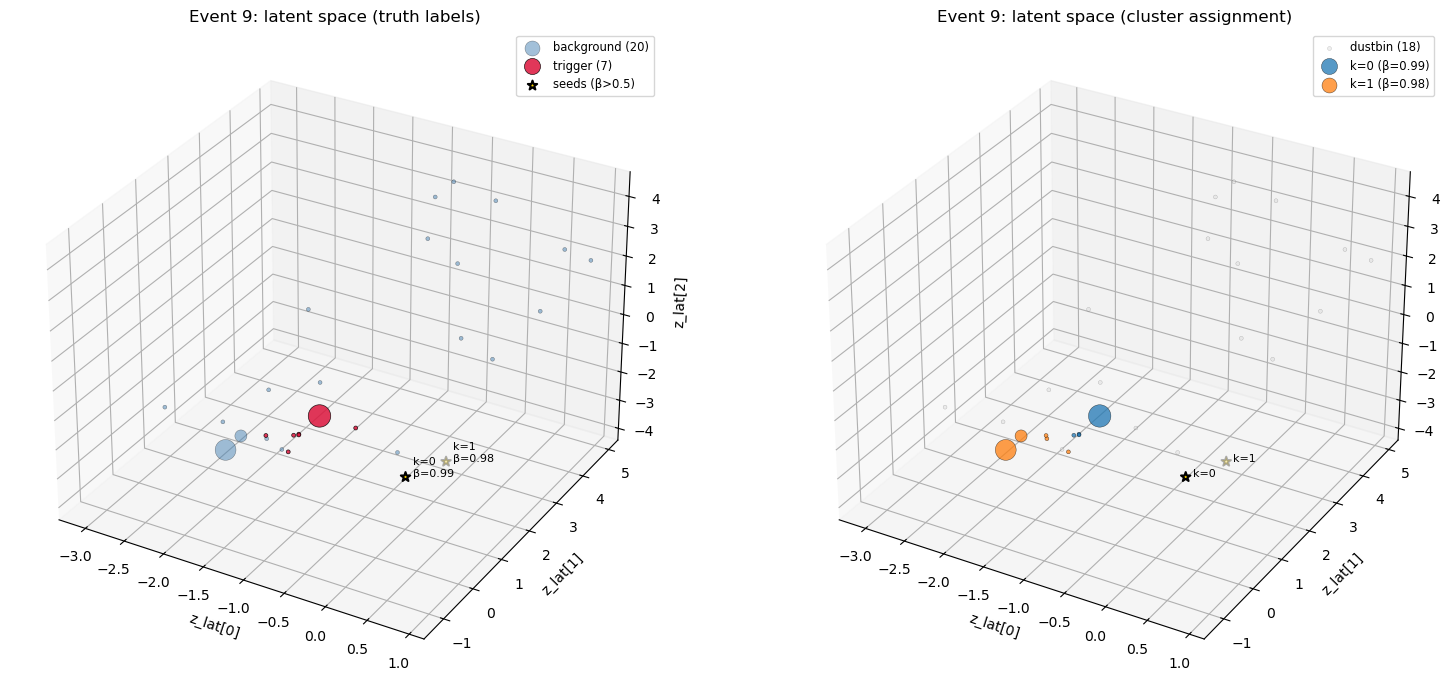


Latent space usage (Event 9):
  z_lat[0]: range [-3.05, +0.89]  std=0.89
  z_lat[1]: range [-1.21, +4.92]  std=2.28
  z_lat[2]: range [-3.83, +4.23]  std=2.03
  Singular values: [13.59  8.71  3.6 ]  (ratio s1/s2=1.6, s1/s3=3.8)
  Effective rank (variance ratio s_i²/s_max²): [1.    0.411 0.07 ]

Latent space summary (Event 9):
  Hit latent norms: min=0.26  max=5.94  mean=3.28  std=1.83
  Seed-seed latent distances:
    k0 ↔ k1: 0.852
  Trigger-hit → seed latent distances:
    hit 0: k0=1.42  k1=1.69
    hit 1: k0=1.05  k1=1.20
    hit 2: k0=1.63  k1=2.08
    hit 3: k0=1.33  k1=1.71
    hit 4: k0=1.32  k1=1.71
    hit 5: k0=1.40  k1=1.81
    hit 6: k0=1.37  k1=1.76


In [25]:
plot_lyso_latent_space(val_dataset, model, event_idx=9)

In [21]:
import pyarrow.parquet as pq
import numpy as np

parquet_path = "training_4_30/data.parquet"
df = pq.read_table(parquet_path).to_pandas()

# Find events with at least 4 origin=0 LYSO hits and dump them
shown = 0
for idx, row in df.iterrows():
    if len(row.get('lyso_origin', [])) == 0: continue
    origins = np.asarray(row['lyso_origin'])
    if (origins == 0).sum() < 4: continue
    
    t = np.asarray(row['lyso_t'])
    e = np.asarray(row['lyso_E'])
    pdg = np.asarray(row['lyso_pdg'])
    s = np.asarray(row['lyso_slice'])
    mask = origins == 0
    
    print(f"\n=== Event {idx}: {mask.sum()} origin=0 LYSO hits ===")
    sorted_data = sorted(zip(t[mask], e[mask], pdg[mask], s[mask]))
    for ti, ei, pi, si in sorted_data:
        print(f"  t={ti:10.3f}  E={ei:8.3f} MeV  pdg={pi:6}  slice={si}")
    
    # Spread metric
    times = np.array([row[0] for row in sorted_data])
    energies = np.array([row[1] for row in sorted_data])
    print(f"  --> time range: {times.max() - times.min():.3f}")
    print(f"  --> energy-weighted std: {np.sqrt(np.average((times - np.average(times, weights=energies))**2, weights=energies)):.3f}")
    
    shown += 1
    if shown >= 5: break



=== Event 0: 9 origin=0 LYSO hits ===
  t=    23.554  E=   1.274 MeV  pdg=    24  slice=8
  t=    24.476  E=  58.488 MeV  pdg=    28  slice=8
  t=    24.750  E=   0.205 MeV  pdg=    24  slice=8
  t=    24.796  E=   0.535 MeV  pdg=    56  slice=8
  t=    24.984  E=   1.281 MeV  pdg=    56  slice=8
  t=    25.025  E=   2.842 MeV  pdg=    56  slice=8
  t=    25.753  E=   0.100 MeV  pdg=     8  slice=8
  t=    25.880  E=   3.607 MeV  pdg=    60  slice=8
  t=    25.999  E=   0.411 MeV  pdg=    24  slice=8
  --> time range: 2.446
  --> energy-weighted std: 0.378

=== Event 2: 4 origin=0 LYSO hits ===
  t=   247.794  E=   1.506 MeV  pdg=    56  slice=5
  t=   248.230  E=  34.615 MeV  pdg=    60  slice=5
  t=   249.041  E=   1.097 MeV  pdg=    24  slice=5
  t=   249.138  E=   0.242 MeV  pdg=    56  slice=5
  --> time range: 1.344
  --> energy-weighted std: 0.179

=== Event 4: 6 origin=0 LYSO hits ===
  t=     3.027  E=   0.886 MeV  pdg=    24  slice=5
  t=     3.688  E=   1.022 MeV  pdg=    5